In [2]:
## Phase 4: Unsupervised Classification


In [3]:
# imports

import pandas as pd  
from sklearn.ensemble import IsolationForest  
from sklearn.preprocessing import StandardScaler  
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [4]:
# import data

df = pd.read_csv("../data/metrics.csv")

In [10]:
# feature construction

df['AstTO_Ratio'] = df['AvgAssists'] / (df['AvgTurnovers'])

In [11]:
unsupervised_features = [
    'AvgScoreDiff', 'WinPct', 'AvgPointsFor', 
    'AvgPointsAgainst', 'MasseyRankMean', 'AstTO_Ratio', 'AvgRebounds']

In [12]:
X_unsupervised = df[unsupervised_features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_unsupervised)

In [13]:
isolation_forest = IsolationForest(n_estimators = 200, contamination = 0.05, random_state = 42)
isolation_forest.fit(X_scaled)
df['Isolation_Score'] = isolation_forest.decision_function(X_scaled)
df['Is_Anomaly'] = isolation_forest.predict(X_scaled)

In [14]:
top_anomalies = df.sort_values('Isolation_Score').head(10)
top_anomalies

,Season,TeamID,GamesPlayed,Wins,Losses,AvgPointsFor,AvgPointsAgainst,AvgScoreDiff,AvgAssists,AvgTurnovers,...,MaxTourneyDayNum,RoundReachedNum,RoundReached,MadeTournament,TourneyWins,TourneyLosses,Isolation_Score,Is_Anomaly,CinderellaFlag,AstTO_Ratio
7797,2025,1290,29,1,28,52.448276,82.275862,-29.827586,7.896552,15.000000,...,NaN,NaN,NaN,0,0,0,-0.128061,-1,Not Cinderella,0.526437
6230,2021,1152,9,0,9,55.444444,88.666667,-33.222222,9.888889,14.555556,...,NaN,NaN,NaN,0,0,0,-0.119426,-1,Not Cinderella,0.679389
5585,2019,1211,33,30,3,88.848485,65.060606,23.787879,18.212121,10.363636,...,145.0,9.0,R9,1,3,1,-0.103736,-1,Not Cinderella,1.757310
1224,2006,1366,27,1,26,55.000000,82.777778,-27.777778,8.481481,20.481481,...,NaN,NaN,NaN,0,0,0,-0.100537,-1,Not Cinderella,0.414105
5085,2017,1417,33,29,4,90.363636,75.333333,15.030303,21.484848,11.545455,...,144.0,8.0,R8,1,2,1,-0.100126,-1,Not Cinderella,1.860892
7691,2025,1181,34,31,3,82.705882,61.911765,20.794118,16.764706,9.205882,...,152.0,11.0,R11,1,4,1,-0.098368,-1,Not Cinderella,1.821086
890,2005,1366,28,0,28,57.964286,81.214286,-23.250000,7.642857,19.607143,...,NaN,NaN,NaN,0,0,0,-0.097967,-1,Not Cinderella,0.389800
6237,2021,1159,15,14,1,86.333333,68.600000,17.733333,17.666667,9.800000,...,137.0,2.0,R2,1,0,1,-0.093415,-1,Not Cinderella,1.802721
1850,2008,1314,34,32,2,88.705882,72.735294,15.970588,16.735294,14.676471,...,152.0,10.0,R10,1,4,1,-0.089132,-1,Not Cinderella,1.140281
8109,2026,1237,30,5,25,80.866667,89.166667,-8.300000,18.933333,11.633333,...,NaN,NaN,NaN,0,0,0,-0.088887,-1,Not Cinderella,1.627507


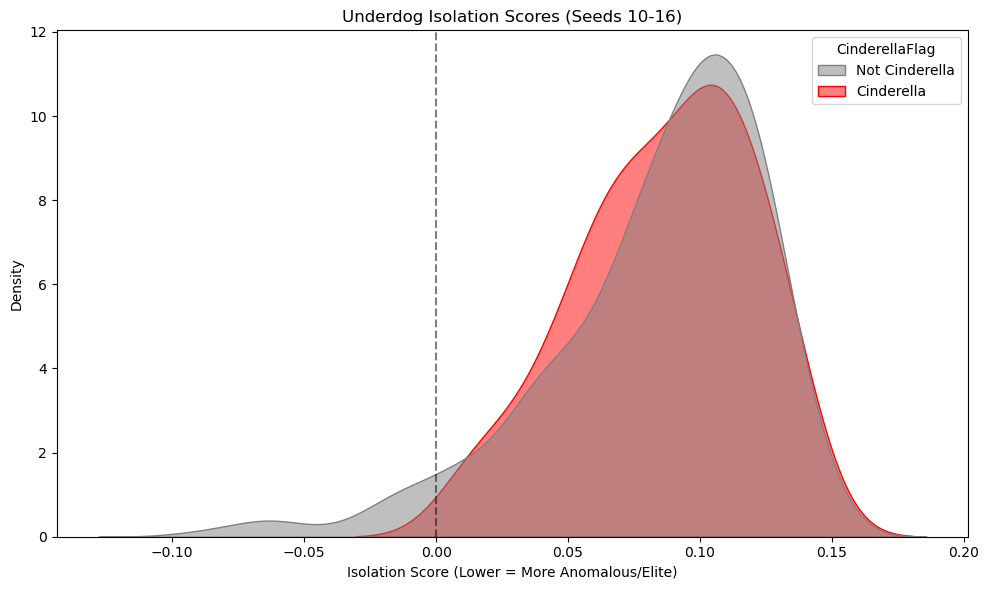

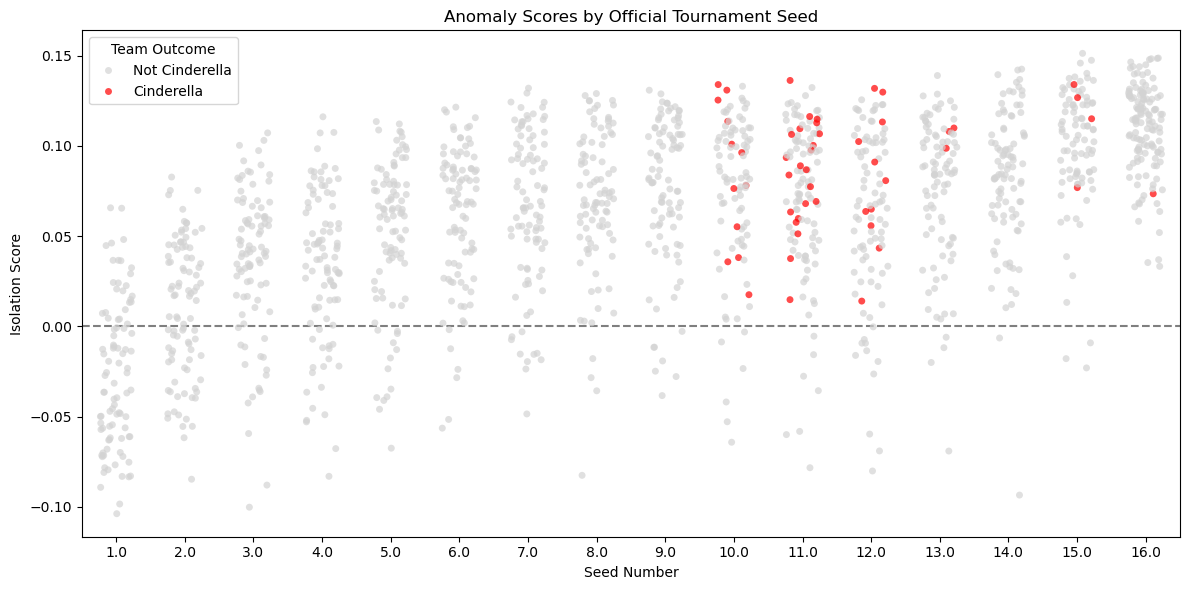

In [15]:
# We want to identify cinderella teams by looking for teams with at least 2 tournament wins while being a higher seed (10+)
df['CinderellaFlag'] = np.where(
    (df['SeedNum'] >= 10) & (df['TourneyWins'] >= 2),
    'Cinderella',
    'Not Cinderella'
)

tourney_teams = df[df['SeedNum'].notna()].copy()
underdogs = tourney_teams[tourney_teams['SeedNum'] >= 10]

# plot 1
plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=underdogs, 
    x='Isolation_Score', 
    hue='CinderellaFlag', 
    fill=True, 
    common_norm=False, # Allows both curves to reach full height for easy comparison
    palette={'Not Cinderella': 'gray', 'Cinderella': 'red'},
    alpha=0.5
)
plt.title('Underdog Isolation Scores (Seeds 10-16)')
plt.xlabel('Isolation Score (Lower = More Anomalous/Elite)')
plt.ylabel('Density')
plt.axvline(0, color='black', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# plot 2
plt.figure(figsize=(12, 6))
sns.stripplot(
    data=tourney_teams, 
    x='SeedNum', 
    y='Isolation_Score', 
    hue='CinderellaFlag',
    palette={'Not Cinderella': 'lightgray', 'Cinderella': 'red'},
    alpha=0.7,
    jitter=0.25,
    size=5
)
plt.title('Anomaly Scores by Official Tournament Seed')
plt.xlabel('Seed Number')
plt.ylabel('Isolation Score')
plt.axhline(0, color='black', linestyle='--', alpha=0.5)

# Fix the legend so it doesn't double-print
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[:2], labels[:2], title='Team Outcome')

plt.tight_layout()
plt.show()

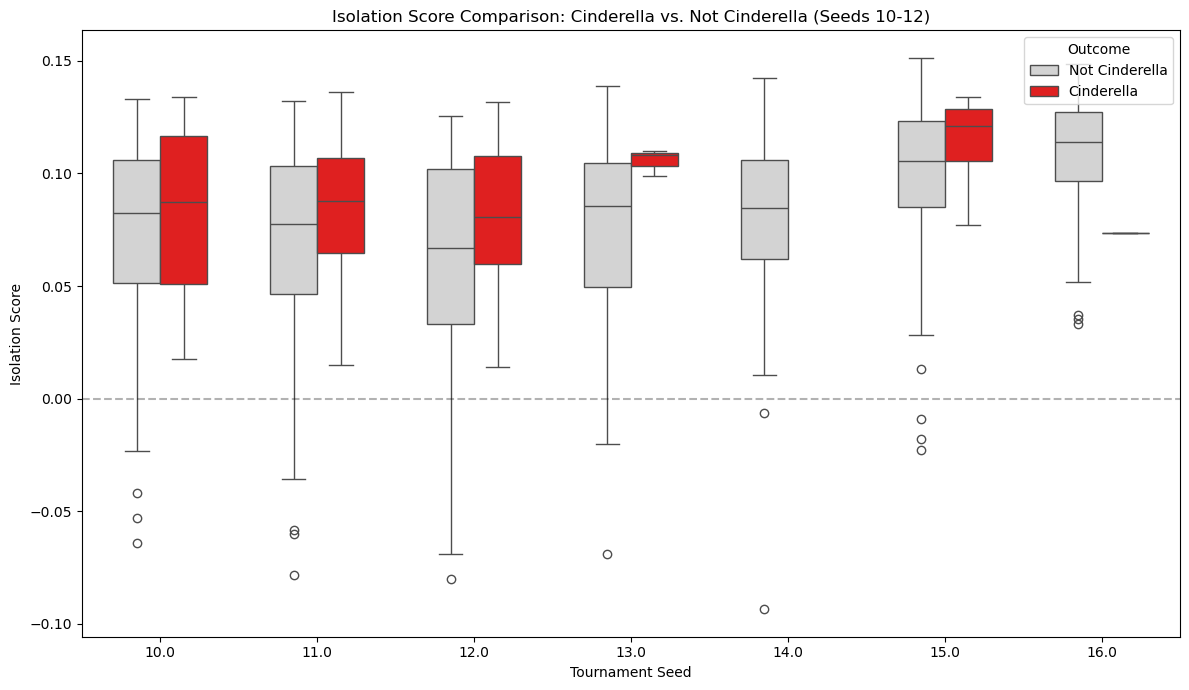

In [16]:
stratified_seeds = [10, 11, 12, 13, 14, 15, 16]
df_stratified = df[df['SeedNum'].isin(stratified_seeds)].copy()

# 2. Ensure CinderellaFlag is clearly defined
df_stratified['CinderellaFlag'] = np.where(
    (df_stratified['TourneyWins'] >= 2),
    'Cinderella',
    'Not Cinderella'
)

# 3. Create the stratified boxplot
plt.figure(figsize=(12, 7))
sns.boxplot(
    data=df_stratified,
    x='SeedNum',
    y='Isolation_Score',
    hue='CinderellaFlag',
    palette={'Not Cinderella': 'lightgray', 'Cinderella': 'red'},
    width=0.6
)

plt.title('Isolation Score Comparison: Cinderella vs. Not Cinderella (Seeds 10-12)')
plt.xlabel('Tournament Seed')
plt.ylabel('Isolation Score')
plt.axhline(0, color='black', linestyle='--', alpha=0.3)

plt.legend(title='Outcome', loc='upper right')
plt.tight_layout()
plt.show()

### Visualization Takeaways: The Indistinguishable Cinderella

Based on the anomaly score distributions, we observed the following key findings:

**Indistinguishable Profiles:** Cinderella teams are largely indistinguishable from non-Cinderella teams. They consistently fall within the same distribution and, based upon our unsupervised regular-season features, do not appear mathematically different from standard early-exit teams.
**Refuting the Hypothesis:** We initially assumed that Cinderella teams would need to be more negative-leaning (highly anomalous) to pull off an upset. However, the data shows that historical Cinderellas tended to have Isolation Scores spread across the standard distribution of their respective seeds. 
**Lack of Variance:** Cinderella teams did not stand out significantly as statistical outliers compared to other members of their seed line. 